<a href="https://colab.research.google.com/github/mafaiziyas/Wearable-AI-Barbell-Activity-Recognition-and-Rep-Counting-Engine/blob/main/scripts/Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
train_data = pd.read_csv("/content/drive/MyDrive/Fitness Tracker/Intermediate Data Files (post Data_preprocessing)/train.csv")
train_data.head()
train_data.columns

Index(['epoch (ms)', 'acc_x (g)', 'acc_y (g)', 'acc_z (g)', 'gyr_x (deg/s)',
       'gyr_y (deg/s)', 'gyr_z (deg/s)', 'participant', 'label', 'category',
       'set'],
      dtype='object')

In [35]:
set_df = train_data.loc[train_data["set"]==3]
set_df.head()

,epoch (ms),acc_x (g),acc_y (g),acc_z (g),gyr_x (deg/s),gyr_y (deg/s),gyr_z (deg/s),participant,label,category,set
308,2019-01-11 15:38:55.000,-0.0660,0.924,0.0420,-1.524333,-6.280333,1.483667,A,ohp,heavy1,3.0
309,2019-01-11 15:38:55.100,-0.0590,0.878,0.0520,3.384000,-6.829500,-2.439000,A,ohp,heavy1,3.0
310,2019-01-11 15:38:55.200,-0.0665,0.947,0.0605,9.004000,-3.699333,-2.073000,A,ohp,heavy1,3.0
311,2019-01-11 15:38:55.300,-0.1090,1.348,0.0600,0.488000,-2.500000,-0.457000,A,ohp,heavy1,3.0
312,2019-01-11 15:38:55.400,-0.1350,1.432,0.0210,20.101333,3.679000,-35.060667,A,ohp,heavy1,3.0


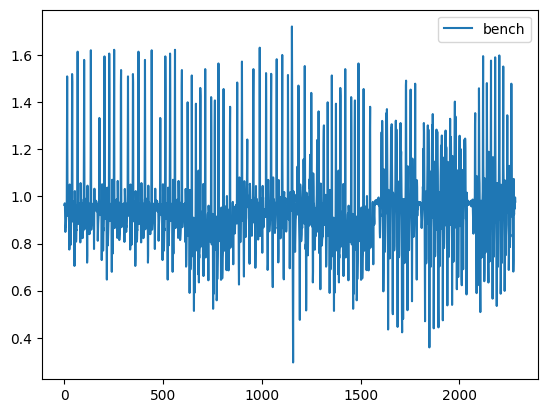

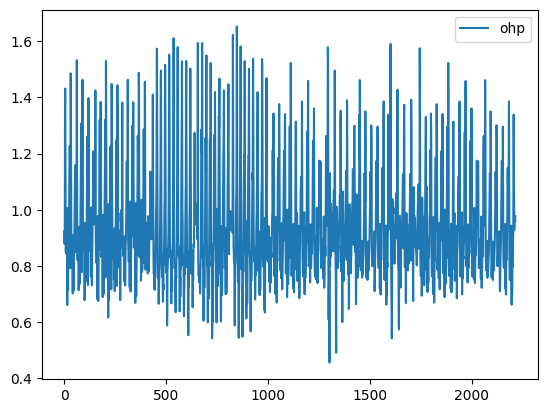

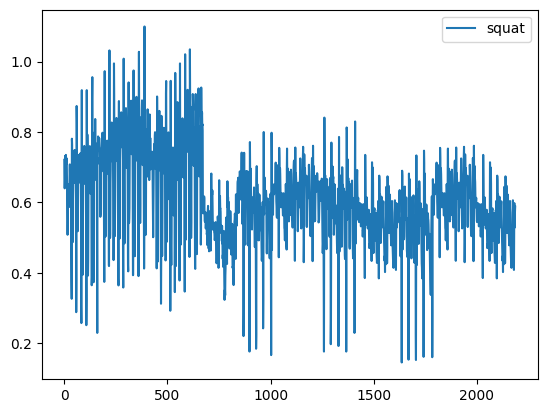

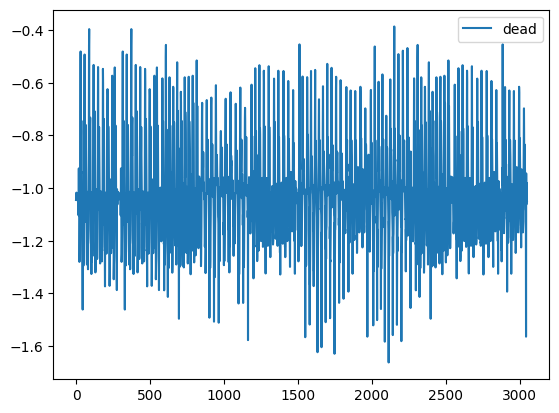

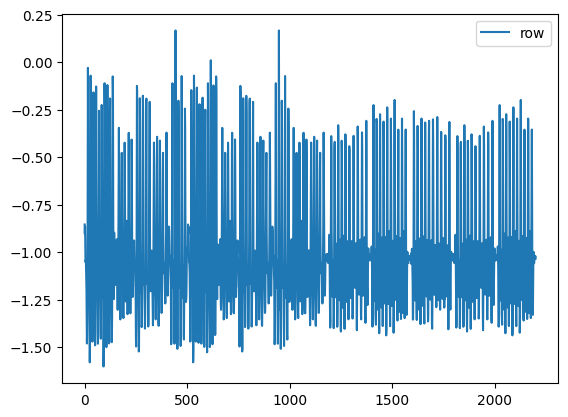

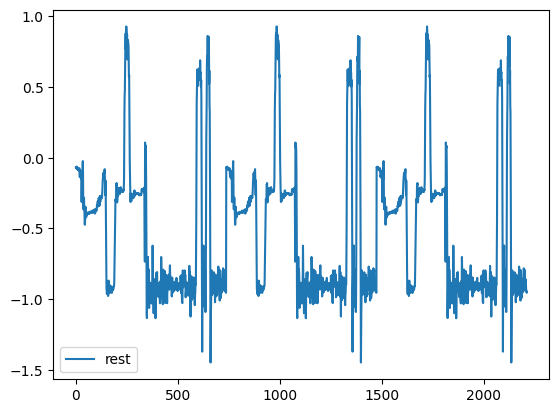

In [37]:
for label in train_data["label"].unique():
  subset = train_data.loc[train_data["label"]==label]
  fig, ax = plt.subplots()
  plt.plot(subset['acc_y (g)'].reset_index(drop=True), label=label)
  plt.legend()
  plt.show()

In [ ]:
#Plotting accelerometer Data against each excercise to see the distiction

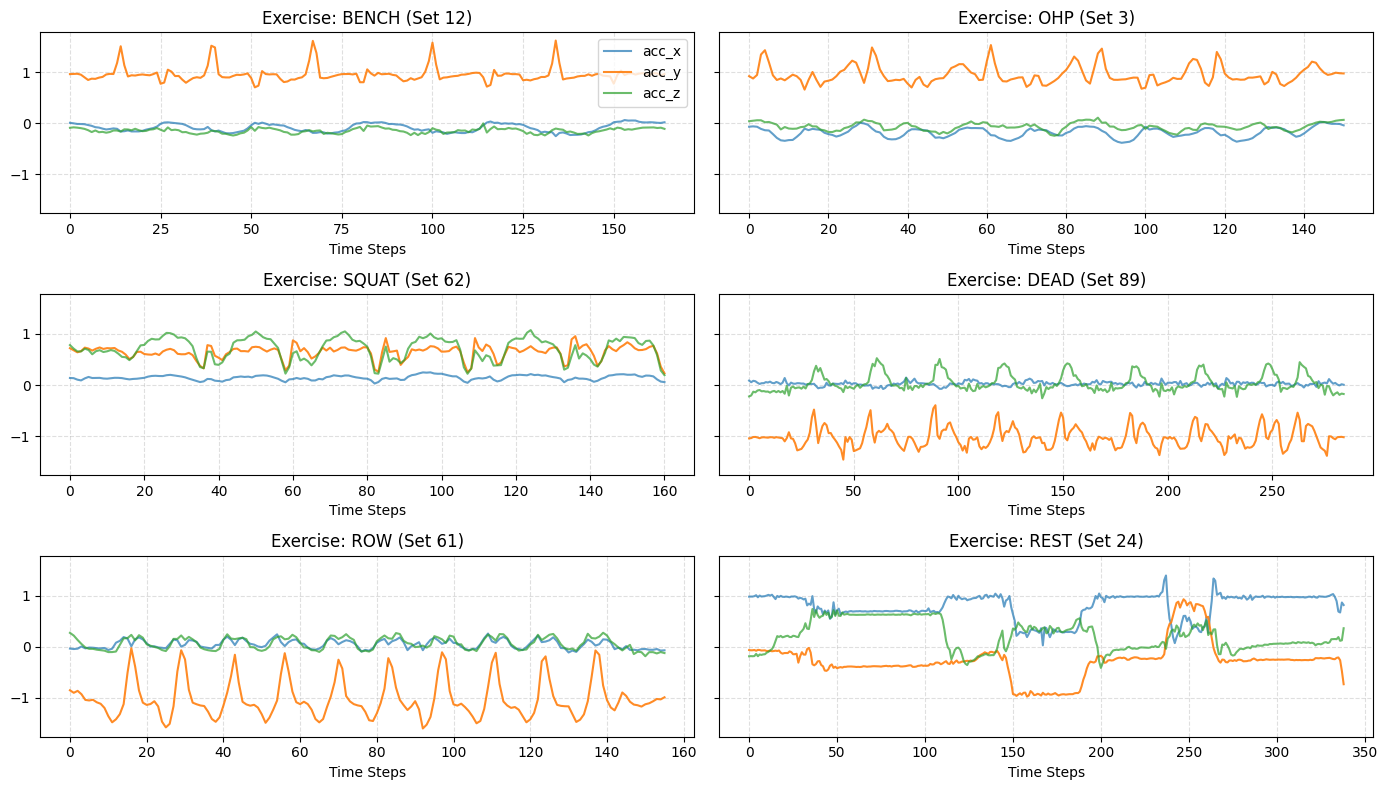

In [39]:
labels = train_data["label"].unique()
fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for i, label in enumerate(labels):
    # Selecting the first set for the given exercise label
    first_set = train_data[train_data["label"] == label]["set"].iloc[0]
    subset = train_data[
        (train_data["label"] == label) & (train_data["set"] == first_set)
    ].reset_index(drop=True)

    # Plotting x, y, z accelerometer axes
    axes[i].plot(subset["acc_x (g)"], label="acc_x", alpha=0.7)
    axes[i].plot(subset["acc_y (g)"], label="acc_y", alpha=0.9)
    axes[i].plot(subset["acc_z (g)"], label="acc_z", alpha=0.7)

    axes[i].set_title(f"Exercise: {label.upper()} (Set {int(first_set)})")
    axes[i].set_xlabel("Time Steps")
    axes[i].grid(True, linestyle="--", alpha=0.4)
    if i == 0:
        axes[i].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [30]:
#Plotting Gyroscope Data against each excercise to see the distiction

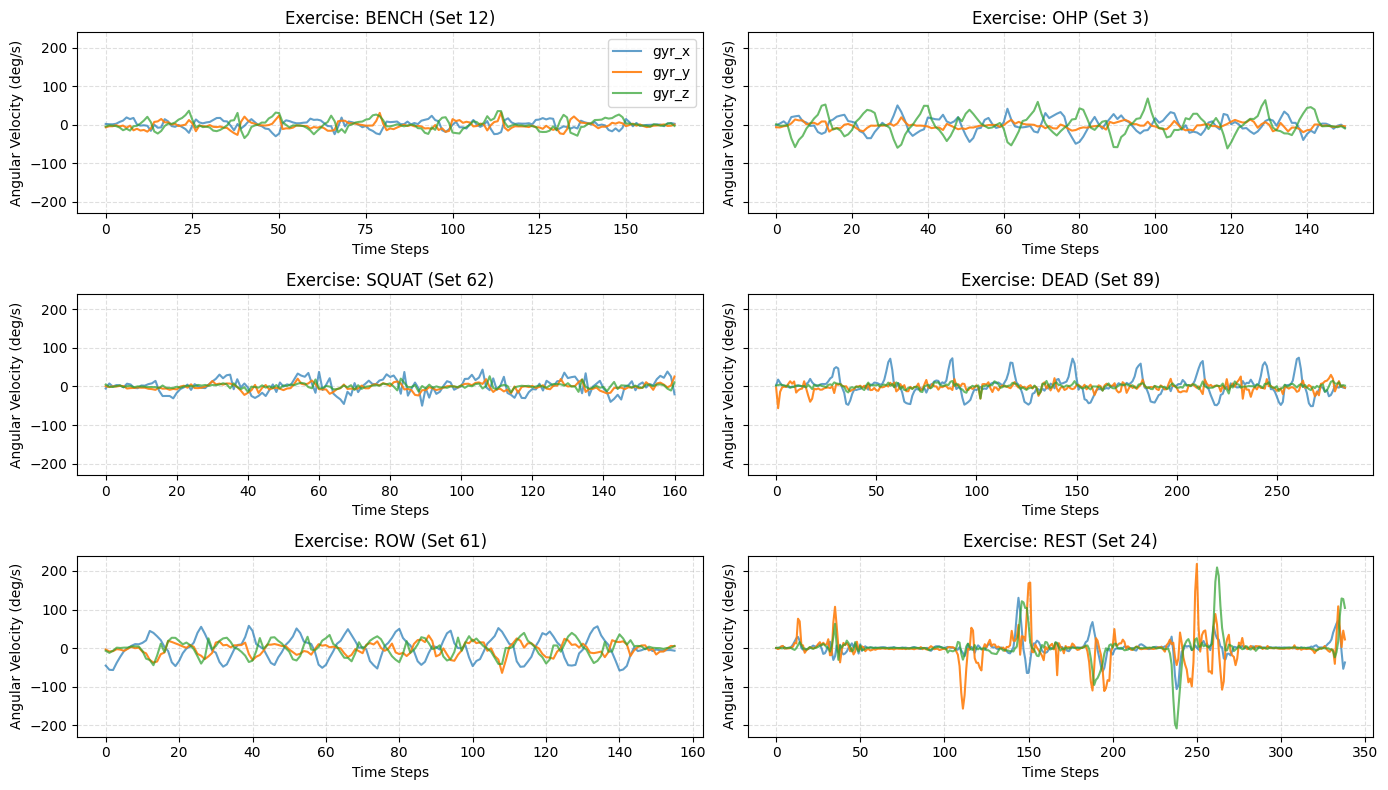

In [40]:
labels = train_data["label"].unique()
fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for i, label in enumerate(labels):
    # Select the first set for the given exercise label
    first_set = train_data[train_data["label"] == label]["set"].iloc[0]
    subset = train_data[
        (train_data["label"] == label) & (train_data["set"] == first_set)
    ].reset_index(drop=True)

    # Plotting x, y, z gyroscope axes
    axes[i].plot(subset["gyr_x (deg/s)"], label="gyr_x", alpha=0.7)
    axes[i].plot(subset["gyr_y (deg/s)"], label="gyr_y", alpha=0.9)
    axes[i].plot(subset["gyr_z (deg/s)"], label="gyr_z", alpha=0.7)

    axes[i].set_title(f"Exercise: {label.upper()} (Set {int(first_set)})")
    axes[i].set_xlabel("Time Steps")
    axes[i].set_ylabel("Angular Velocity (deg/s)")
    axes[i].grid(True, linestyle="--", alpha=0.4)
    if i == 0:
        axes[i].legend(loc="upper right")

plt.tight_layout()
plt.show()